# Workshop 5: Four Rocks, Four Fates
## Exploring the Inner Solar System Through Mission Data

**NPSC2002: Space Exploration : Science, Technology and Industry**

---

Four planets formed from the same swirling disk of gas and dust. Same raw ingredients. Same neighbourhood. Same star.

Today, one is a scorched, airless rock swinging in an elliptical orbit. One is a hellish pressure cooker hot enough to melt lead. One teems with life. One is a frozen, ancient desert with dried river valleys.

This workshop asks: **why?**

And it answers that question the way planetary scientists do: by sending machines to look, and reading what they brought back.

---

**How to use this notebook:** Most code is pre-written. Your job is to **run each cell**, **read the outputs carefully**, and **answer the reflection questions** in your own words. The culminating task in Part 6 contributes to your workshop grade.

## Learning Objectives

By the end of this workshop you will be able to:

- Interpret orbital and bulk property data for the four inner planets
- Explain how specific missions were designed to answer specific scientific questions, and what those missions taught us
- Identify patterns and anomalies in planetary data and form scientific explanations
- Fit an exponential model to real atmospheric profile data and extract physical meaning from it
- Evaluate which planetary properties are most important for habitability



---
## Part 1 · Setup

In [1]:
# Run this cell first.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import requests, io

NAVY  = '#0B1A2F'
GOLD  = '#C9A84C'
LIGHT = '#E8E8E8'
GREY  = '#8899AA'

PLANET_COLORS = {
    'Mercury': '#B5B5B5',
    'Venus':   '#E8C84A',
    'Earth':   '#4A9FD9',
    'Mars':    '#E06040',
    'Jupiter': '#C88B3A',
}

plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': NAVY,
    'axes.edgecolor': GREY, 'axes.labelcolor': LIGHT,
    'xtick.color': LIGHT, 'ytick.color': LIGHT,
    'text.color': LIGHT, 'grid.color': '#1E3050',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'legend.facecolor': '#0F2540', 'legend.edgecolor': GREY,
    'font.size': 10, 'figure.dpi': 120,
})

INNER_PLANETS = ['Mercury', 'Venus', 'Earth', 'Mars']
COLORS = [PLANET_COLORS[p] for p in INNER_PLANETS]
print("Setup complete.")

Setup complete.


---
## Part 2 · The Neighbourhood
### "Where are these worlds, and can we even reach them?"

Before the Space Age, the inner planets were bright points of light: visible, but unknowable in detail. The fundamental question was simple: what are the basic orbital facts, and can we get a spacecraft there?

The **Mariner program** (NASA, 1962-1973) was humanity's first systematic attempt to answer that question. Mariner 2 made the first successful planetary flyby, past Venus in 1962, confirming that its surface was far hotter than many scientists expected. Mariner 4 returned the first close-up images of Mars in 1965, revealing a cratered, seemingly dead landscape rather than the canal-crossed world some had imagined. Mariner 10 used a Venus gravity assist to reach Mercury in 1974-75, the only spacecraft to visit that world until MESSENGER arrived in orbit in 2011.

What the Mariner missions taught us: the inner planets are not scaled versions of each other. Even basic flyby data revealed they are fundamentally, strikingly different. **WHY?**

---

The orbital data below comes from NASA's JPL Horizons system, the authoritative source for solar system positional data used by mission designers worldwide.

In [2]:
# Orbital data for the inner planets plus Jupiter for scale reference.
# Source: NASA JPL Horizons / NASA Planetary Fact Sheet

orbital_data = {
    'Planet':                 ['Mercury','Venus', 'Earth', 'Mars',  'Jupiter'],
    'Semi-major axis (AU)':   [ 0.387,   0.723,   1.000,   1.524,   5.203  ],
    'Eccentricity':           [ 0.206,   0.007,   0.017,   0.093,   0.049  ],
    'Orbital period (days)':  [87.97,   224.70,  365.25,  686.97, 4332.59 ],
    'Inclination (deg)':      [ 7.00,    3.39,    0.00,    1.85,    1.30   ],
}

df_orb = pd.DataFrame(orbital_data).set_index('Planet')

display(df_orb.style
    .set_caption("Table 1: Inner Solar System Orbital Properties (NASA JPL Horizons)")
    .format({'Semi-major axis (AU)': '{:.3f}', 'Eccentricity': '{:.3f}',
             'Orbital period (days)': '{:.2f}', 'Inclination (deg)': '{:.2f}'})
    .set_properties(**{'text-align': 'center'}))

,Semi-major axis (AU),Eccentricity,Orbital period (days),Inclination (deg)
Planet,,,,
Mercury,0.387,0.206,87.97,7.00
Venus,0.723,0.007,224.70,3.39
Earth,1.000,0.017,365.25,0.00
Mars,1.524,0.093,686.97,1.85
Jupiter,5.203,0.049,4332.59,1.30


### The solar system to scale, with real orbital shapes

Most diagrams of the solar system show circular orbits. Most planetary orbits are *nearly* circular, but not quite. Mercury's eccentricity of 0.206 is substantial: its distance from the Sun varies between 0.31 AU at perihelion and 0.47 AU at aphelion. Mars similarly swings between 1.38 and 1.67 AU.

The plot below draws actual ellipses using each planet's measured semi-major axis and eccentricity. Jupiter is included to give a sense of scale: the four inner planets are crowded into a small fraction of the space out to Jupiter.

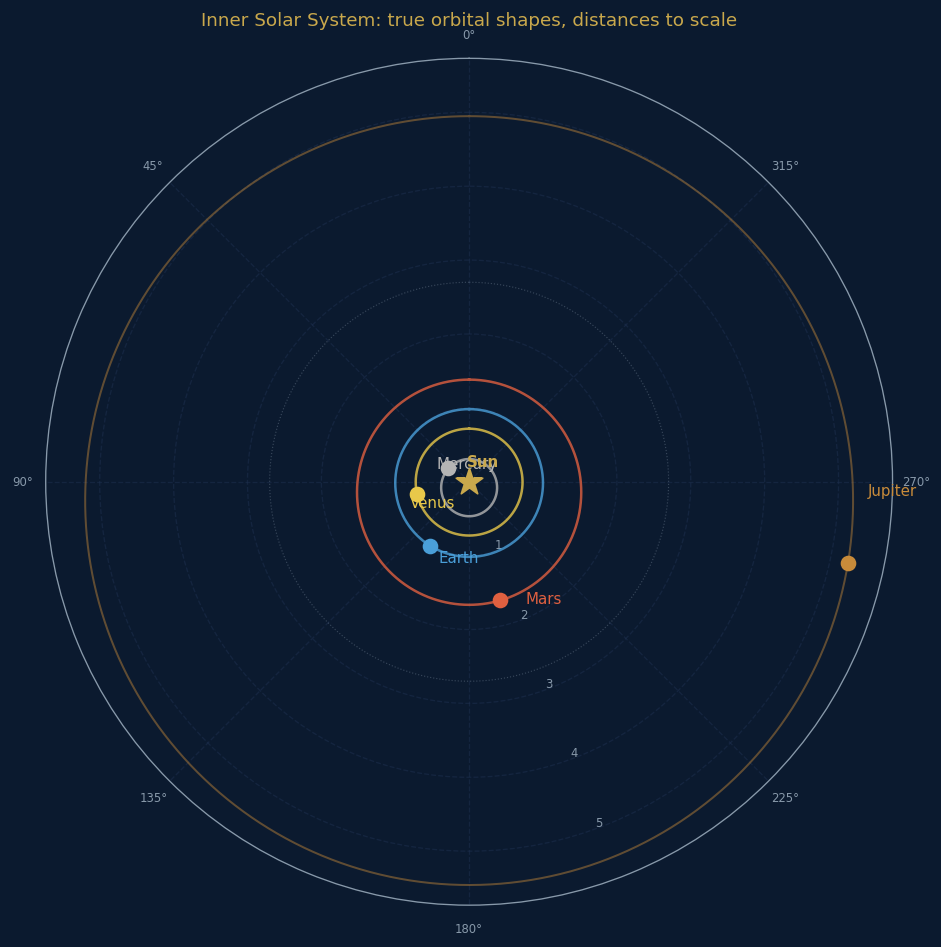

Planet      Perihelion (AU)  Aphelion (AU)   Range (AU)
------------------------------------------------------
Mercury               0.307          0.467        0.159
Venus                 0.718          0.728        0.010
Earth                 0.983          1.017        0.034
Mars                  1.382          1.666        0.283


In [3]:
# Orbital map: true elliptical shapes, distances to scale.
# Polar ellipse: r(theta) = a(1 - e^2) / (1 + e*cos(theta))
# The Sun sits at one focus. Planet markers are placed on the orbit line.

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

theta = np.linspace(0, 2 * np.pi, 1000)

# Angles at which to place the planet dot and label (spread to avoid overlap)
label_angles = {
    'Mercury': 1.0, 'Venus': 1.8, 'Earth': 2.6, 'Mars': 3.4, 'Jupiter': 4.5
}
all_planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter']

for planet in all_planets:
    a = df_orb.loc[planet, 'Semi-major axis (AU)']
    e = df_orb.loc[planet, 'Eccentricity']
    r = a * (1 - e**2) / (1 + e * np.cos(theta))

    lw    = 1.5 if planet != 'Jupiter' else 1.2
    alpha = 0.8 if planet != 'Jupiter' else 0.45
    ax.plot(theta, r, color=PLANET_COLORS[planet], lw=lw, alpha=alpha)

    # Place the planet dot ON the orbit line at the chosen angle
    t0   = label_angles[planet]
    r0   = a * (1 - e**2) / (1 + e * np.cos(t0))
    ax.scatter([t0], [r0], color=PLANET_COLORS[planet], s=70, zorder=6)
    ax.annotate(planet, xy=(t0, r0), xytext=(t0 + 0.18, r0 + 0.15),
                color=PLANET_COLORS[planet], fontsize=9)

# Sun at origin
ax.scatter([0], [0], color=GOLD, s=280, zorder=7, marker='*')
ax.annotate('Sun', xy=(0, 0), xytext=(0.12, 0.22), color=GOLD,
            fontsize=9, fontweight='bold')

# Asteroid belt (approximate)
ax.plot(theta, np.full_like(theta, 2.7), color=GREY, lw=0.7,
        linestyle=':', alpha=0.35, label='Asteroid belt (~2.7 AU)')

ax.set_theta_zero_location('N')
ax.set_rlabel_position(200)
ax.tick_params(colors=GREY, labelsize=7)
ax.set_title('Inner Solar System: true orbital shapes, distances to scale',
             color=GOLD, fontsize=11, pad=20)
plt.tight_layout()
plt.show()

# Perihelion/aphelion table to make the ellipse shapes concrete
print(f"{'Planet':<10} {'Perihelion (AU)':>16} {'Aphelion (AU)':>14} {'Range (AU)':>12}")
print("-" * 54)
for planet in ['Mercury', 'Venus', 'Earth', 'Mars']:
    a = df_orb.loc[planet, 'Semi-major axis (AU)']
    e = df_orb.loc[planet, 'Eccentricity']
    print(f"{planet:<10} {a*(1-e):>16.3f} {a*(1+e):>14.3f} {2*a*e:>12.3f}")

### Reflection 2.1

**a.** Mercury's orbit ranges from 0.31 to 0.47 AU. Solar flux scales as 1/r². How much more solar energy does Mercury receive at perihelion compared to aphelion?

**b.** Jupiter is included for perspective. How does the spread of the inner planets compare to the distance out to Jupiter? What practical implication does this have for missions that need to reach the outer solar system?

**c.** Based on orbital distance alone, write down your prediction for the ranking of mean surface temperatures from hottest to coldest. Keep this: Part 4 will test it against the actual data.

*Double-click this cell to write your answers.*

---
**a.** 1/r²(perihelion)/1/r²(aphelion) = (r(aphelion)/r(perihelion))² = (0.47/0.31)² = 2.29 = 129%
Therefore Mercury receives around 130% more solar energy at perihelion than aphelion.

**b.** All of the inner planets orbit the Sun within 1.5 AU, with variances in distances from eccentric orbits ranging from 0.010 to 0.159 AU. However, Jupiter has an orbit around 5.2 AU away from the Sun, more than 3 times as far from the Sun as Mars, and has a 0.51 AU range between the perihelion and aphelion. These massive distances must be taken into consideration when planning future missions in the outer solar system, so optimal power and fuel sources must be found.

**c.** Based on orbital distances, Mercury should have the hottest surface temperature, then every planet afterwards should decrease in temperature as distance from the Sun increases.

---
## Part 3 · Under the Hood
### "Are the other terrestrial planets fundamentally like Earth?"

Flybys told us the planets were different. But to understand *why*, scientists needed to measure their masses, densities, and internal structures: properties that reveal what a planet is made of, and how it evolved.

**How do we actually measure these things from a spacecraft?**

*Mass* is measured by tracking a spacecraft's radio signal very precisely as it orbits. Gravity pulls on the spacecraft, and any variation in the gravitational field (caused by density differences inside the planet) shows up as tiny Doppler shifts in the transmitted signal. This technique, called radio science or gravity field mapping, has been used on virtually every orbiter since the 1970s.

*Radius* comes from radar altimetry (bouncing radio pulses off the surface and timing the return) combined with limb imaging (photographing the planet's edge against space).

*Density* follows directly from mass divided by volume. But what density *tells you* is more interesting. A planet with density similar to rock (~3,000 kg/m3) has little or no metallic iron core. A planet as dense as Mercury (~5,400 kg/m3) must have a massive iron core, because rock alone cannot produce that value.

Key missions that gave us these numbers:

- **Magellan** (NASA, 1989-1994) used radar to map Venus through its impenetrable cloud cover, revealing a geologically young volcanic surface with no evidence of plate tectonics. Precise orbit tracking gave us Venus's internal mass distribution.
- **MESSENGER** (NASA, 2011-2015), the first spacecraft to orbit Mercury, confirmed that Mercury's iron core extends to roughly 85% of the planet's radius: enormous compared to Earth's ~55%. The leading explanation is a giant impact early in solar system history that stripped away most of Mercury's rocky mantle.
- **Mars Global Surveyor** and **Mars Reconnaissance Orbiter** measured Mars's gravity field precisely enough to constrain the size of its iron core, confirming it is small and at least partially solidified, unlike Earth's still-active magnetic dynamo.

In [4]:
# Bulk and surface properties of the inner planets.
# Source: NASA Planetary Fact Sheet (nssdc.gsfc.nasa.gov/planetary/factsheet)
# All values derived from spacecraft measurements (radio science, radar altimetry, lander data).

bulk_data = {
    'Planet':                   ['Mercury', 'Venus',   'Earth',   'Mars'  ],
    'Mass (10^24 kg)':          [ 0.330,    4.870,     5.970,     0.642  ],
    'Radius (km)':              [ 2439.7,   6051.8,    6371.0,    3389.5 ],
    'Density (kg/m3)':          [ 5429,     5243,      5514,      3933   ],
    'Surface gravity (m/s2)':   [ 3.7,      8.9,       9.8,       3.7    ],
    'Escape velocity (km/s)':   [ 4.3,      10.4,      11.2,      5.0    ],
    'Mean surface temp (C)':    [ 167,      464,       15,       -65     ],
    'Atm. pressure (bar)':      [ 0.0,      92.0,      1.014,     0.00636],
}

df_bulk = pd.DataFrame(bulk_data).set_index('Planet')

display(df_bulk.style
    .set_caption("Table 2: Inner Planet Bulk and Surface Properties (NASA Planetary Fact Sheet)")
    .format({'Mass (10^24 kg)': '{:.3f}', 'Radius (km)': '{:.1f}',
             'Density (kg/m3)': '{:.0f}', 'Surface gravity (m/s2)': '{:.1f}',
             'Escape velocity (km/s)': '{:.1f}', 'Mean surface temp (C)': '{:.0f}',
             'Atm. pressure (bar)': '{:.5f}'})
    .set_properties(**{'text-align': 'center'}))

,Mass (10^24 kg),Radius (km),Density (kg/m3),Surface gravity (m/s2),Escape velocity (km/s),Mean surface temp (C),Atm. pressure (bar)
Planet,,,,,,,
Mercury,0.330,2439.7,5429,3.7,4.3,167,0.00000
Venus,4.870,6051.8,5243,8.9,10.4,464,92.00000
Earth,5.970,6371.0,5514,9.8,11.2,15,1.01400
Mars,0.642,3389.5,3933,3.7,5.0,-65,0.00636


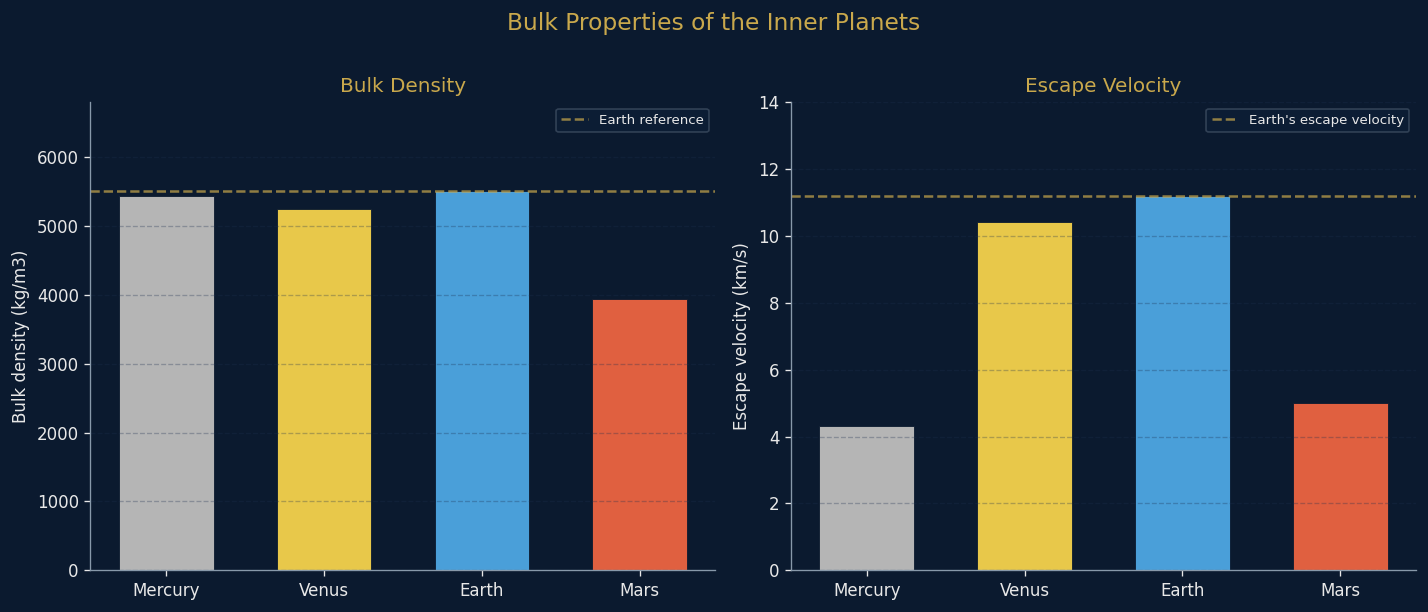

In [5]:
# Density and escape velocity comparison.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Density
ax = axes[0]
ax.bar(INNER_PLANETS, df_bulk['Density (kg/m3)'], color=COLORS,
       edgecolor=NAVY, linewidth=0.5, width=0.6)
ax.axhline(df_bulk.loc['Earth', 'Density (kg/m3)'], color=GOLD,
           linestyle='--', alpha=0.7, lw=1.5, label='Earth reference')
ax.set_ylabel('Bulk density (kg/m3)')
ax.set_title('Bulk Density', color=GOLD, fontsize=12)
ax.legend(fontsize=8, framealpha=0.3)
ax.set_ylim(0, 6800)

# Escape velocity
ax = axes[1]
ax.bar(INNER_PLANETS, df_bulk['Escape velocity (km/s)'], color=COLORS,
       edgecolor=NAVY, linewidth=0.5, width=0.6)
ax.axhline(11.2, color=GOLD, linestyle='--', alpha=0.7, lw=1.5,
           label="Earth's escape velocity")
ax.set_ylabel('Escape velocity (km/s)')
ax.set_title('Escape Velocity', color=GOLD, fontsize=12)
ax.legend(fontsize=8, framealpha=0.3)
ax.set_ylim(0, 14)

for ax in axes:
    ax.set_facecolor(NAVY)
    ax.tick_params(colors=LIGHT)
    for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Bulk Properties of the Inner Planets', color=GOLD, fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Reflection 3.1

**a.** Mercury and Mars have identical surface gravity (3.7 m/s²) but very different densities (5,429 vs 3,933 kg/m3). How is this possible? What does the difference in density suggest about their internal compositions?

**b.** Mercury is nearly as dense as Earth despite being far smaller. MESSENGER confirmed its iron core extends to ~85% of its radius, compared to ~55% for Earth. A giant impact early in solar system history is the leading explanation. What would such an impact have removed, and why would a metal-rich remnant be left behind?

**c.** Mars has a lower escape velocity than Earth. Looking at the escape velocity chart, does that alone explain why Mars has lost most of its atmosphere? What other factor, measured by MAVEN, is needed to complete the explanation?

**d.** Mass is measured via Doppler shifts in a spacecraft's radio signal. What does this tell you about the relationship between precision engineering, telecommunications, and planetary science? Could we have known these density values without the Space Age?

*Double-click this cell to write your answers.*

---
**a.** Since gravity follows an inverse square rule in respect to distance, as its formula is GM/R². Mercury has a much smaller mass than Mars, but its radius is also smaller, so observers on the surface of Mercury would be "closer" to the centre of mass of Mercury. Due to Mercury's high density and low radius, it has a similar surface gravity to Mars with a lower density and larger radius. Mercury's high density indicates a large dense iron core, while Mars' low density indicates a composition of lighter minerals like silicate and a smaller metallic core

**b.** Such a large impact would have removed a lot of lighter minerals near the surface of the planet, leaving the heavier elements closer to the core undisturbed.

**c.** The lower escape velocity of Mars means that more atmospheric particles have enough kinetic energy to escape, but this only accounts for the atmosphere very slowly losing mass over billions of years, not enough to explain why the majority of its atmosphere is gone. The other factor to the loss of atmosphere is the loss of Mars' global magnetic field during its first billion years of formation, due to the smaller size of the planet compared to Earth. Without a strong magnetic field, solar winds rapidly stripped away Mars' atmosphere by ionising the gases and knocking them into space.

**d.** Precision engineering involves measuring the smallest changes in frequency using stable and accurate instruments, telecommunications involve transmitting powerful signals at precise frequencies into space and managing the return signals to measure frequency shifts, and planetary science drives the need for both of these in order to analyse the gravitational pull on a satellite, causing the Doppler effect, so the mass and gravitational strength of a planet can be determined by combining those observations with radius measurements obtained by imagery. Before the Space Age, the masses of planets were estimated by observing the orbits of their natural moons using basic ground based telescopes. This allowed them to distinguish the gas giants from the rocky planets, but it was limited by the accuracy of optical measurements without the use of satellites.

---
## Part 4 · The Atmosphere Question
### "Why does each planet have, or not have, an atmosphere?"

This is where things get strange. Venus's atmospheric pressure is 92 times Earth's. Mars's is less than 1% of Earth's. Mercury has essentially none. And escape velocity alone does not explain it: Venus and Earth have almost identical escape velocities.

Three missions transformed our understanding:

- **Venera program** (Soviet Union, 1961-1984): After many failures, Venera 7 (1970) became the first spacecraft to successfully transmit data from another planet's surface. It survived 23 minutes before being destroyed, long enough to confirm ~465°C and crushing pressure. The greenhouse effect was not just a theoretical prediction: it was *measured directly*, in the most dramatic possible way. Later Venera probes photographed a volcanic landscape.
- **Viking landers** (NASA, 1976): Landed on Mars, sampled the soil for signs of life, and returned detailed atmospheric data. The thin CO2 atmosphere (less than 1% of Earth's pressure), absence of liquid water, and intense UV radiation painted a picture of a cold, sterile desert, though the question of *past* habitability remains open.
- **MAVEN** (NASA, 2014-present): Still orbiting Mars today, measuring the rate at which the solar wind strips away atmospheric gases. MAVEN showed Mars loses roughly 100 grams of atmosphere per second to space. When Mars's magnetic field collapsed around 4 billion years ago, this process accelerated dramatically, and Mars lost most of what it had.

Key finding: losing your magnetic field means losing your atmosphere. Losing your atmosphere means losing your water.

In [6]:
# Major atmospheric composition by volume (%).
# Mercury's "atmosphere" is a thin exosphere of surface-sputtered atoms, not a true atmosphere.

atm_comp = {
    'Planet':    ['Mercury', 'Venus',  'Earth',  'Mars'  ],
    'CO2 (%)':  [  0.0,      96.5,     0.04,     95.3   ],
    'N2 (%)':   [  0.0,       3.5,    78.10,      2.7   ],
    'O2 (%)':   [  0.0,       0.0,    20.90,      0.13  ],
    'Ar (%)':   [  0.0,       0.0,     0.93,      1.6   ],
    'Other (%)':[ 100.0,      0.0,     0.03,      0.27  ],
}
df_atm = pd.DataFrame(atm_comp).set_index('Planet')
display(df_atm.style
    .set_caption("Table 3: Atmospheric Composition (% by volume)")
    .format('{:.2f}')
    .set_properties(**{'text-align': 'center'}))

,CO2 (%),N2 (%),O2 (%),Ar (%),Other (%)
Planet,,,,,
Mercury,0.00,0.00,0.00,0.00,100.00
Venus,96.50,3.50,0.00,0.00,0.00
Earth,0.04,78.10,20.90,0.93,0.03
Mars,95.30,2.70,0.13,1.60,0.27


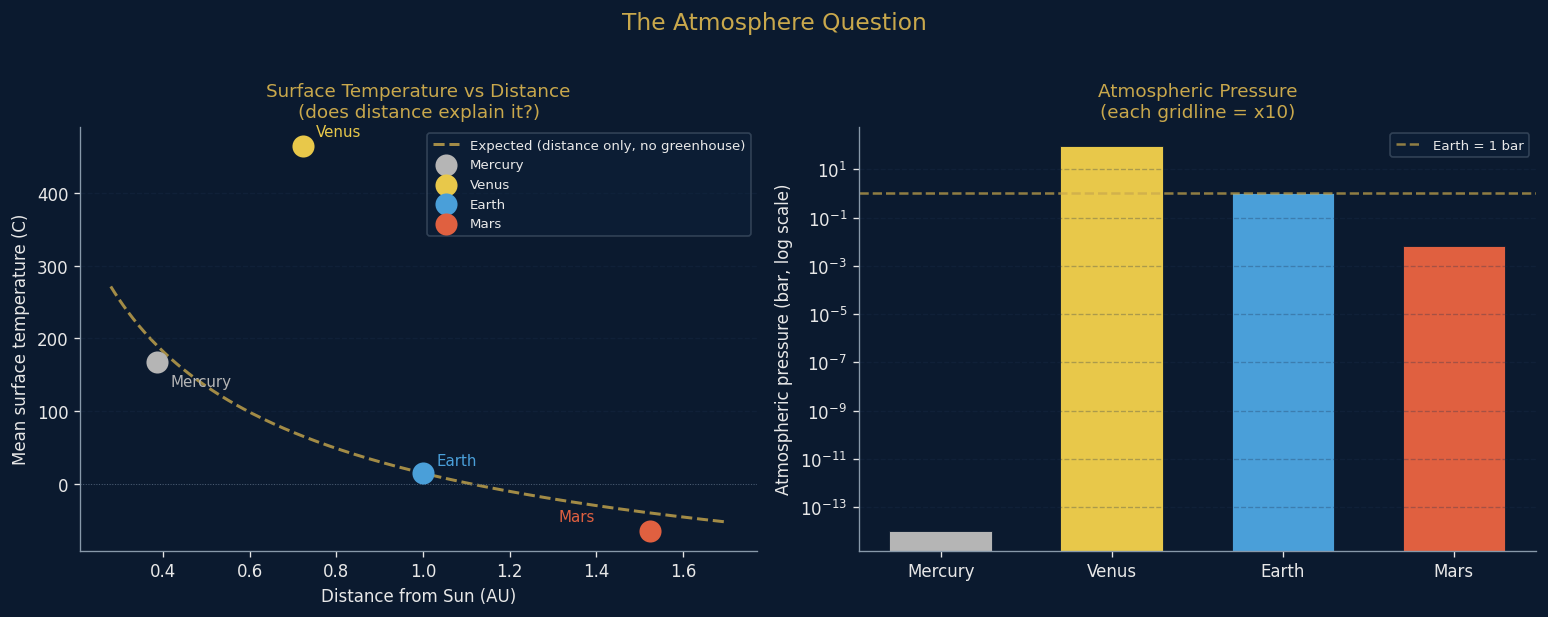

In [7]:
# Two questions in one figure:
# Left: does distance from the Sun predict surface temperature?
# Right: how do atmospheric pressures compare?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: temperature vs distance
ax = axes[0]
a_range = np.linspace(0.28, 1.7, 300)
T_eq_C = 288 * (1.0 / a_range) ** 0.5 - 273
ax.plot(a_range, T_eq_C, color=GOLD, lw=1.8, linestyle='--', alpha=0.8,
        label='Expected (distance only, no greenhouse)', zorder=1)

for planet in INNER_PLANETS:
    a    = df_orb.loc[planet, 'Semi-major axis (AU)']
    temp = df_bulk.loc[planet, 'Mean surface temp (C)']
    ax.scatter(a, temp, color=PLANET_COLORS[planet], s=150, zorder=5, label=planet)
    offsets = {'Mercury': (8, -14), 'Venus': (8, 6), 'Earth': (8, 5), 'Mars': (-55, 6)}
    ax.annotate(planet, (a, temp), xytext=offsets[planet],
                textcoords='offset points', color=PLANET_COLORS[planet], fontsize=9)

ax.axhline(0, color=GREY, lw=0.6, linestyle=':', alpha=0.5)
ax.set_xlabel('Distance from Sun (AU)')
ax.set_ylabel('Mean surface temperature (C)')
ax.set_title('Surface Temperature vs Distance\n(does distance explain it?)',
             color=GOLD, fontsize=11)
ax.legend(fontsize=8, framealpha=0.3, loc='upper right')

# Right: atmospheric pressure on a log scale
ax = axes[1]
pressures = df_bulk['Atm. pressure (bar)'].copy()
pressures['Mercury'] = 1e-14
bar_vals = [pressures[p] for p in INNER_PLANETS]
ax.bar(INNER_PLANETS, bar_vals, color=COLORS, edgecolor=NAVY, linewidth=0.5, width=0.6)
ax.set_yscale('log')
ax.axhline(1.0, color=GOLD, linestyle='--', alpha=0.7, lw=1.5, label='Earth = 1 bar')
ax.set_ylabel('Atmospheric pressure (bar, log scale)')
ax.set_title('Atmospheric Pressure\n(each gridline = x10)', color=GOLD, fontsize=11)
ax.legend(fontsize=8, framealpha=0.3)

for ax in axes:
    ax.set_facecolor(NAVY)
    ax.tick_params(colors=LIGHT)
    for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('The Atmosphere Question', color=GOLD, fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### The Venus anomaly

Look at the left chart. Venus is farther from the Sun than Mercury, yet its mean surface temperature is 464°C compared to Mercury's 167°C. Venus receives less solar energy, but is almost 300°C hotter.

This is the greenhouse effect, not as a model, but as a measurement. The Venera probes confirmed an atmosphere that is 96.5% CO2, creating a runaway feedback loop that has baked the planet for billions of years. Sunlight enters; heat cannot escape.

Venus is sometimes called Earth's "evil twin": similar size, similar mass, similar escape velocity. Understanding why it turned out so differently is one of the most important open questions in planetary science.

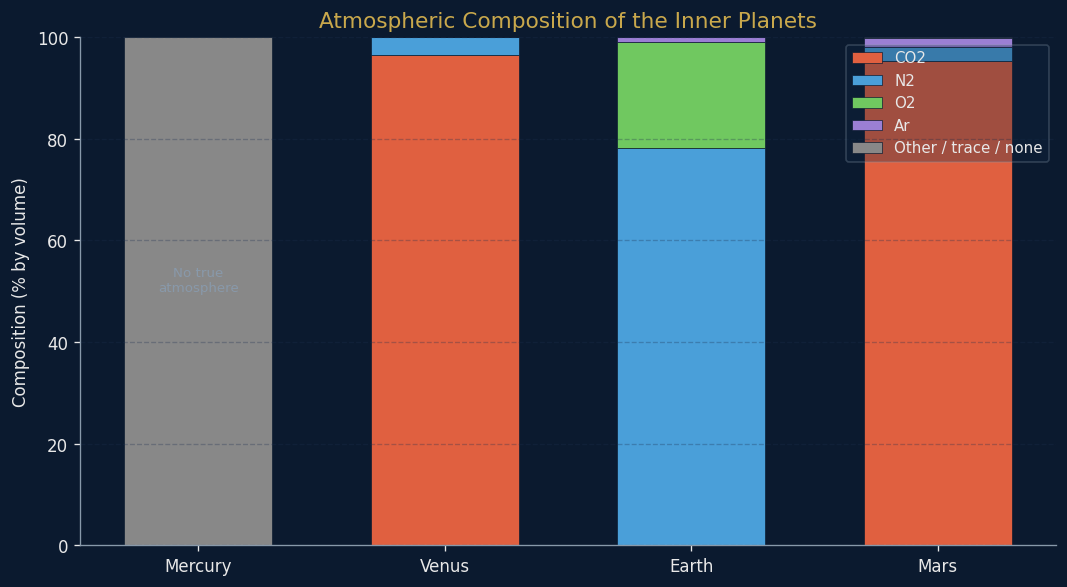

In [8]:
# Atmospheric composition as a stacked bar chart.

fig, ax = plt.subplots(figsize=(9, 5))
components  = ['CO2 (%)', 'N2 (%)', 'O2 (%)', 'Ar (%)', 'Other (%)']
comp_colors = ['#E06040', '#4A9FD9', '#70C860', '#9B7FD4', '#888888']
comp_labels = ['CO2', 'N2', 'O2', 'Ar', 'Other / trace / none']
bottom = np.zeros(4)
for comp, color, label in zip(components, comp_colors, comp_labels):
    vals = df_atm[comp].values
    ax.bar(INNER_PLANETS, vals, bottom=bottom, color=color,
           label=label, edgecolor=NAVY, linewidth=0.4, width=0.6)
    bottom += vals
ax.set_ylabel('Composition (% by volume)')
ax.set_title('Atmospheric Composition of the Inner Planets', color=GOLD, fontsize=13)
ax.legend(loc='upper right', fontsize=9, framealpha=0.3)
ax.text(0, 50, 'No true\natmosphere', ha='center', color=GREY, fontsize=8)
ax.set_facecolor(NAVY)
ax.tick_params(colors=LIGHT)
for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Reflection 4.1

**a.** Check your temperature prediction from Reflection 2.1c against the actual data. Which planet most dramatically violates the expected pattern, and why?

**b.** Venus and Earth have almost identical escape velocities (~10-11 km/s), yet their atmospheric pressures differ by a factor of ~90. What does this tell you about the limits of escape velocity as an explanation for atmospheric retention?

**c.** Venera probes survived only 23-127 minutes on Venus's surface before being destroyed. What does this design constraint tell you about the scientific tradeoffs in planetary mission design? What measurements can *only* a lander provide that an orbiter cannot?

**d.** The atmospheric pressure bar chart uses a logarithmic y-axis. Why is a log scale more informative than a linear one for this data? What would the chart look like on a linear scale, and what information would be lost?

*Double-click this cell to write your answers.*

---
**a.** Unlike the prediction based on orbital distances, Venus has by far the hottest surface temperature, due to the much denser atmosphere trapping heat from the Sun without releasing it into space.

**b.** Escape velocity is merely a threshold for stability, it does not determine the amount of atmosphere that the planet can hold, although it can explain why planets can lose atmosphere. The density of Venus' atmosphere could be explained by the lack of carbon trapped in the ground, unlike Earth which trapped carbon in the ground and water, so less carbon dioxide is in the Earth's atmosphere. As Venus grew hotter, more of the lighter gases in its atmosphere escaped, leaving only the heavier carbon dioxide and creating a denser atmosphere which caused the surface temperature to rise even more.

**c.** Landers we sent to the surface of Venus cannot endure the extreme heat and pressures. Trying to make them more durable by adding titanium pressure spheres and thermal insulation meant that less mass for scientific instruments was available, and the heavy protection was still far from enough to withstand the surface of Venus for a long amount of time. Due to their short lifespan, fast automated science sequences were required without any time for recalibration or repeating experiments. The probes had to be rigid and stationary, so they were not able to make any observations outside the landing zone.

**d.**

---
## Part 5 · Reading the Data That Missions Returned
### Atmospheric density profiles from MAVEN

So far we have been using summary values from the NASA Planetary Fact Sheet: single numbers representing complex, variable phenomena. In this part, you will work with something closer to the raw science: an atmospheric density profile from the MAVEN mission at Mars.

**What is an atmospheric density profile?**

Rather than a single surface pressure number, a density profile tells you how atmospheric density changes with altitude. This matters enormously for mission design: spacecraft entering a planetary atmosphere during aerobraking need to know how much drag they will encounter at every altitude. It also tells us about atmospheric structure, temperature, and composition at different heights.

**How does MAVEN measure this?**

MAVEN's Neutral Gas and Ion Mass Spectrometer (NGIMS) directly samples atmospheric particles as the spacecraft dips into the upper atmosphere at periapsis. By recording density at each altitude during the orbit, it builds up a profile.

**What does the profile tell us about physics?**

In a gravitationally bound atmosphere at roughly constant temperature, density decreases exponentially with altitude. This is described by the scale height H:

$$\rho(z) = \rho_0 \cdot e^{-z/H}$$

where H = RT / (Mg), R is the gas constant, T is temperature, M is molar mass, and g is surface gravity. A larger scale height means the atmosphere extends higher before thinning out. Comparing scale heights across planets reveals how gravity, temperature, and atmospheric composition interact.

The data below is derived from archived MAVEN NGIMS periapsis observations, representative of typical inbound passes at moderate solar activity.

In [ ]:
# Load Mars atmospheric density profile data.
# Source: NASA PDS Atmospheres Node, MAVEN NGIMS archive.
# Pre-cleaned version hosted on GitHub for reproducibility.

MAVEN_URL = ("https://raw.githubusercontent.com/jensenlawrence/"
             "NPSC2002/main/data/maven_co2_density_profile.csv")

try:
    resp = requests.get(MAVEN_URL, timeout=8)
    resp.raise_for_status()
    df_maven = pd.read_csv(io.StringIO(resp.text))
    print("Loaded MAVEN data from GitHub.")
except Exception:
    print("GitHub data unavailable: using representative synthetic profile.")
    print("Values are consistent with published MAVEN NGIMS observations.")
    print("(Reference: Mahaffy et al. 2015, Science 350, aad0210)")
    rng = np.random.default_rng(42)
    altitudes = np.arange(120, 222, 2, dtype=float)
    H_true   = 10.8          # km, representative CO2 scale height
    n0_true  = 1.4e18        # molecules/m3 at 120 km (Mahaffy et al. 2015)
    n_clean  = n0_true * np.exp(-(altitudes - 120) / H_true)
    noise    = rng.normal(0, 0.10, len(altitudes))
    n_noisy  = n_clean * (1 + noise)
    df_maven = pd.DataFrame({
        'altitude_km':    altitudes,
        'co2_density_m3': np.maximum(n_noisy, 1e10),
    })

print(f"\nData: {df_maven.shape[0]} rows x {df_maven.shape[1]} columns")
display(df_maven.head())

In [ ]:
# Plot 1: raw CO2 density profile.
# Altitude is on the vertical axis throughout this section (conventional for atmospheric profiles).

fig, ax = plt.subplots(figsize=(6, 7))

ax.scatter(df_maven['co2_density_m3'], df_maven['altitude_km'],
           color=PLANET_COLORS['Mars'], s=25, alpha=0.75,
           label='MAVEN NGIMS (CO2)', zorder=4)

ax.set_xscale('log')
ax.set_xlabel('CO2 number density (molecules/m3, log scale)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Mars Atmospheric CO2 Density Profile\nMAVEN NGIMS instrument',
             color=GOLD, fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.set_facecolor(NAVY)
ax.tick_params(colors=LIGHT)
for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Linearising the exponential

The exponential relationship $\rho = \rho_0 \cdot e^{-z/H}$ is easier to work with if we take the natural logarithm of both sides:

$$\ln(\rho) = \ln(\rho_0) - \frac{z}{H}$$

This is the equation of a straight line: altitude z on the vertical axis, ln(density) on the horizontal axis, with slope -1/H. If the atmosphere really does follow an exponential profile, the log-transformed data should fall on a straight line. Let's check.

In [ ]:
# Plot 2: log-transformed density.
# Taking ln(density) should linearise the exponential: the result should be a straight line.

ln_density = np.log(df_maven['co2_density_m3'])
altitude   = df_maven['altitude_km']

fig, ax = plt.subplots(figsize=(6, 7))

ax.scatter(ln_density, altitude,
           color=PLANET_COLORS['Mars'], s=25, alpha=0.75,
           label='ln(CO2 density)', zorder=4)

ax.set_xlabel('ln(CO2 number density)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Log-transformed density profile\n(should be linear if exponential atmosphere)',
             color=GOLD, fontsize=11)
ax.legend(fontsize=9, framealpha=0.3)
ax.set_facecolor(NAVY)
ax.tick_params(colors=LIGHT)
for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Fit a straight line to altitude vs ln(density) to extract the scale height H.
# We fit: altitude = intercept + slope * ln_density
# Rearranging the exponential model: z = H*ln(rho0) - H*ln(rho)
# So slope of altitude vs ln_density = -H  =>  H = -slope

slope, intercept = np.polyfit(ln_density, altitude, 1)
H_measured = -slope    # scale height in km

print(f"Fitted slope:            {slope:.4f} km per unit ln(density)")
print(f"Measured scale height H: {H_measured:.2f} km")
print()

# Theoretical scale height: H = RT / (Mg)
R      = 8.314    # J / (mol K)
T      = 200.0    # K, approximate temperature in MAVEN altitude range
M_co2  = 0.04401  # kg/mol, CO2
g_mars = 3.72     # m/s2

H_theory = (R * T) / (M_co2 * g_mars) / 1000   # convert m to km
print(f"Theoretical scale height (T = {T} K): {H_theory:.2f} km")
print(f"Difference: {abs(H_measured - H_theory):.2f} km")

# Plot the fit on top of the data
fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(ln_density, altitude,
           color=PLANET_COLORS['Mars'], s=25, alpha=0.75, label='MAVEN data', zorder=4)

ln_fit = np.linspace(ln_density.min(), ln_density.max(), 200)
alt_fit = slope * ln_fit + intercept
ax.plot(ln_fit, alt_fit, color=GOLD, lw=2.0,
        label=f'Linear fit  (H = {H_measured:.1f} km)')

ax.set_xlabel('ln(CO2 number density)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Scale height fit to MAVEN density profile', color=GOLD, fontsize=12)
ax.legend(fontsize=9, framealpha=0.3)
ax.set_facecolor(NAVY)
ax.tick_params(colors=LIGHT)
for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compare scale heights across the three planets with atmospheres.
# H = RT/(Mg) for Venus and Earth (theory); measured from MAVEN fit for Mars.

R = 8.314
H_earth = (R * 255) / (0.029 * 9.8)  / 1000   # N2/O2, T=255 K effective
H_venus = (R * 240) / (0.044 * 8.9)  / 1000   # CO2,   T=240 K upper atm

print(f"Scale heights:  Earth {H_earth:.1f} km  |  Venus {H_venus:.1f} km  |  Mars {H_measured:.1f} km")

planets_H = ['Venus', 'Earth', 'Mars']
H_vals    = [H_venus, H_earth, H_measured]
colors_H  = [PLANET_COLORS[p] for p in planets_H]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(planets_H, H_vals, color=colors_H, edgecolor=NAVY, linewidth=0.5, width=0.5)
for bar, val in zip(bars, H_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f} km', ha='center', va='bottom', color=LIGHT, fontsize=10)
ax.set_ylabel('Atmospheric scale height H (km)')
ax.set_title('Atmospheric Scale Height Comparison', color=GOLD, fontsize=12)
ax.set_facecolor(NAVY)
ax.tick_params(colors=LIGHT)
for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color(GREY)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Mars has the largest scale height of the three, despite having by far the thinnest atmosphere. Scale height and total atmospheric mass are independent quantities: H depends on temperature and the ratio of gravity to molecular mass, while total atmospheric mass is set by how much gas a planet has managed to hold on to over its history. Mars's low gravity and cold upper atmosphere push H upward, even though most of its gas has long since been stripped away.

### Reflection 5.1

**a.** Does the log-transformed density data fall on a straight line? What would it mean physically if it did *not*?

**b.** Your measured scale height for Mars should be close to but not identical to the theoretical value. The simple formula H = RT/(Mg) assumes a constant temperature throughout the column. Why is this an approximation, and in which direction would you expect the real profile to deviate?

**c.** Why does scale height matter for spacecraft engineers designing an aerobraking manoeuvre at Mars?

**d.** MAVEN measures atmospheric escape in real time today. Why is measuring a current process scientifically useful for understanding something that mostly happened 4 billion years ago?

*Double-click this cell to write your answers.*

---
**a.**

**b.**

**c.**

**d.**

---
## Part 6 · Putting It Together: What Makes a Planet Habitable?

You now have data across three dimensions: orbital position, physical structure, and atmospheric conditions. None of them alone explains habitability. What matters is how they interact.

| | Mercury | Venus | Earth | Mars |
|---|---|---|---|---|
| Temp vs expectation | Below (no atmosphere to trap heat) | Far above (runaway greenhouse) | Baseline | Below |
| Atmosphere | Essentially none | Crushing CO2 | Moderate N2/O2 | Thin CO2 |
| Key mission finding | Giant-impact iron core (MESSENGER) | Greenhouse confirmed directly (Venera) | Habitable baseline | Lost magnetic field, lost atmosphere (MAVEN) |
| Biggest open question | Still volcanically active? Water ice at poles? | Still volcanically active today? | Long-term climate stability | Was it ever habitable? |

The pattern that emerges: Earth is not habitable because of any single special property. It sits at a distance where liquid water is possible, has enough mass to hold a nitrogen-oxygen atmosphere, still has an active magnetic dynamo shielding that atmosphere from the solar wind, and has plate tectonics that recycle CO2 to prevent runaway greenhouse warming.

Mars had some of these conditions early on. Evidence of ancient river valleys and lake beds suggests liquid water was once present. MAVEN's measurements suggest Mars's atmosphere was once thick enough to support it. The collapse of Mars's magnetic field roughly 4 billion years ago set the planet on its current trajectory.

In [ ]:
# Multi-factor radar chart: how do the planets compare across five key dimensions?
# All values normalised to Earth = 1. This is a visualisation tool, not a habitability score.

factor_labels = ['Proximity\nto Sun', 'Escape\nvelocity',
                 'Surface\ngravity', 'Bulk\ndensity', 'Atm.\npressure']

raw_vals = {
    'Mercury': [1/0.387,  4.3,  3.7, 5429,  1e-10 ],
    'Venus':   [1/0.723, 10.4,  8.9, 5243,  92.0  ],
    'Earth':   [1/1.000, 11.2,  9.8, 5514,   1.014],
    'Mars':    [1/1.524,  5.0,  3.7, 3933,   0.00636],
}
earth_ref = raw_vals['Earth']
norm_vals = {p: [v/e for v, e in zip(raw_vals[p], earth_ref)] for p in raw_vals}

N      = len(factor_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

for planet in INNER_PLANETS:
    vals = norm_vals[planet] + [norm_vals[planet][0]]
    ax.plot(angles, vals, color=PLANET_COLORS[planet], lw=2, label=planet)
    ax.fill(angles, vals, color=PLANET_COLORS[planet], alpha=0.06)

earth_ring = [1.0]*N + [1.0]
ax.plot(angles, earth_ring, color=GOLD, linestyle='--', lw=1.5, alpha=0.7, label='Earth = 1')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(factor_labels, color=LIGHT, fontsize=9)
ax.set_yticklabels([])
ax.set_ylim(0, 2.8)
ax.spines['polar'].set_color(GREY)
ax.grid(color='#1E3050', linestyle='--', alpha=0.5)
ax.set_title('Multi-factor planetary comparison (Earth = 1)',
             color=GOLD, fontsize=12, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.35, -0.08), fontsize=9, framealpha=0.3)
plt.tight_layout()
plt.show()

print("Points outside the ring: higher than Earth.")
print("Points near the centre: lower than Earth.")

---

Using the data you have worked with across this notebook, write a short argument addressing the following:

> **Of the planetary properties examined in this workshop (orbital distance, escape velocity, atmospheric composition, bulk density, surface temperature) which single property do you consider most important for determining whether a terrestrial planet is habitable? Use at least two specific data values from this workshop to support your argument. Acknowledge at least one limitation of your chosen factor.**

**Guidance:**
- There is no single correct answer: you are assessed on the *quality of reasoning*, not the choice of factor
- Cite specific numbers (e.g. "Venus's escape velocity of 10.4 km/s is nearly identical to Earth's 11.2 km/s, yet...")

*Double-click this cell to write your response.*

---

**Your argument:**

[Write here]


---
## Part 7 · What's Next? Open Questions and Future Missions

The story of the inner solar system is not finished. Several major missions are either active or in development:

**Mercury:** *BepiColombo* (ESA/JAXA) is currently en route, arriving 2026. It will provide far more detailed measurements of Mercury's magnetic field and interior than MESSENGER achieved, and may resolve outstanding questions about the giant impact hypothesis.

**Venus:** *VERITAS* (NASA) and *EnVision* (ESA), both targeting a ~2030 launch, will map Venus's surface in unprecedented detail and look for signs of active volcanism. *DAVINCI* (NASA, ~2030) will fall through Venus's atmosphere sampling its chemistry all the way to the surface: the first atmospheric descent probe at Venus since Vega 2 in 1985.

**Mars:** *Mars Sample Return* (NASA/ESA) aims to retrieve the rock cores already collected by Perseverance and return them to Earth laboratories. If successful, it would allow analysis that no rover instrument can perform, and could finally address whether Mars ever hosted life.

---

### Data and further reading

- NASA Planetary Fact Sheet: https://nssdc.gsfc.nasa.gov/planetary/factsheet/
- NASA JPL Horizons (live orbital data): https://ssd.jpl.nasa.gov/horizons/
- MAVEN mission science: https://lasp.colorado.edu/maven/
- MAVEN NGIMS data archive: https://pds-atmospheres.nmsu.edu/data_and_services/atmospheres_data/MAVEN/maven_main.html
- NASA Planetary Data System: https://pds.nasa.gov/